In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
import matplotlib.pyplot as plt
from neuroaging.visualization import (
    configure_plotting,
    savefig_nice,
    COL_RAW,
    COL_WEIGHTED,
    COL_REF,
    COL_CENSUS,
    CMAP_RAW,
    CMAP_WEIGHTED,
)

configure_plotting()


2026-01-13 14:18:59.210 | INFO     | neuroaging.config:<module>:11 - PROJ_ROOT path is: /home/galkepler/Projects/neuroaging


In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
bad_subjects = ["IN120120"]

In [5]:
metric = ["gm_vol", "adc", "fa", "ad", "rd"]
distribution_metric = "qfmean"
if isinstance(metric, list):
    data_dict = {}
    for m in metric:
        data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
        data["subject_code"] = data["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
        data = (
            data
            .reset_index(drop=True)
            .drop_duplicates(subset=["subject_code", region_col], keep="last")
        )
        data_dict[m] = data[~data["subject_code"].isin(bad_subjects)]
else:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0)
    data["subject_code"] = data["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
    data = (
        data
        .reset_index(drop=True)
        .drop_duplicates(subset=["subject_code", region_col], keep="last")
    )
    data_dict = {metric: data[~data["subject_code"].isin(bad_subjects)]}

/tmp/ipykernel_1777924/781979806.py:6: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_1777924/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_1777924/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_1777924/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,

In [6]:
if isinstance(metric, list):
    data_global_dict = {}
    for m in metric:
        data = data_dict[m]
        if m == "gm_vol":
            data_global = data.drop_duplicates(subset=["subject_code"], keep="first")
            # data_global = data.drop_duplicates(subset=["session_id"], keep="first")
        else:
            data_global = (
                data.groupby("subject_code")
                .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"}) 
                .reset_index()
            )
        data_global_dict[m] = data_global.rename(columns={"total_gm_volume":distribution_metric})
else:
    if metric == "gm_vol":
        data_global = data.drop_duplicates(subset=["subject_code"], keep="first")
        # data_global = data.drop_duplicates(subset=["session_id"], keep="first")
    else:
        data_global = (
            data.groupby("subject_code")
            .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"})
            .reset_index()
        )
        # data_global = (
        #     data.groupby("session_id")
        #     .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"})
        #     .reset_index()
        # )

In [7]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [10]:
from neuroaging.stats import compute_joint_poststrat_weights


In [11]:
age_df = israel_population.copy()
age_df["Population"] = "Population (ref.)"
snbb_age_df = age_df.copy()
snbb_age_df["Population"] = "SNBB"

# convert age_range to pd.IntervalIndex
age_df["age_range"] = pd.IntervalIndex.from_tuples(
    [(int(row["range_start"]), int(min(row["range_end"], 100))) for i, row in age_df.iterrows()]
)

In [12]:
age_df = israel_population.copy()
age_df["Population"] = "Population (ref.)"
snbb_age_df = age_df.copy()
snbb_age_df["Population"] = "SNBB"

# convert age_range to pd.IntervalIndex
age_df["age_range"] = pd.IntervalIndex.from_tuples(
    [(int(row["range_start"]), int(min(row["range_end"], 100))) for i, row in age_df.iterrows()]
)

# simulate ages for the reference population
m = metric[0] if isinstance(metric, list) else metric
data_global = data_global_dict[m] if isinstance(metric, list) else data_global
n_sim = data_global["subject_code"].nunique()
bins = age_df["age_range"].to_numpy()
probs = age_df["total"].values

# How many samples to draw from each bin
np.random.seed(42)  # for reproducibility
counts = np.random.multinomial(n_sim, probs / probs.sum())
# Generate random ages based on the bin edges
# Generate synthetic ages: uniform within each bin
ages_sim = np.hstack(
    [np.random.uniform(low=iv.left, high=iv.right, size=c) for iv, c in zip(bins, counts)]
)
age_df = pd.DataFrame({"age_at_scan": ages_sim})
age_df["Population"] = "Population (ref.)"


if m == "gm_vol":
    snbb_age_df = data_global[
        [
            "age_at_scan",
            "sex",
            "tiv",
            distribution_metric,
            "strip_score",
            "subject_code",
            "session_id",
        ]
    ].rename(columns={distribution_metric: "total_gm_volume"}).copy()
else:
    snbb_age_df = data_global[["age_at_scan", "sex", "subject_code", distribution_metric]].copy()
# snbb_age_df["weight"] = assign_weights_by_population(data=snbb_age_df, population_df=israel_population, age_col="age_at_scan")
# snbb_age_df["weight"], bin_tbl = compute_poststrat_weights(
#     snbb_age_df,
#     israel_population,
#     age_col="age_at_scan",
#     cap=None,  # try None first; if still spiky, use 4 or 5
#     return_bin_table=True,
# )
snbb_age_df["sex"] = snbb_age_df["sex"].map({"M": 0, "F": 1})
snbb_age_df["weight"], bin_tbl = compute_joint_poststrat_weights(
    snbb_age_df,
    israel_population,
    age_col="age_at_scan",
    sex_col="sex",
    return_bin_table=True,
    cap=10  # Optional: prevents any single female/male from having too much influence
)
snbb_age_df["Population"] = "SNBB"

# age_df = pd.concat([age_df, snbb_age_df], ignore_index=True)


In [13]:
import numpy as np
import pandas as pd
from scipy.stats import chisquare, wasserstein_distance
import seaborn as sns
import matplotlib.pyplot as plt
# ────────────────────────────────────────────────────────────────
# Column names (change if yours differ)
AGE_COL = "age_at_scan"  # SNBB person-level ages
WEIGHT_COL = "weight"  # survey weights (will be overwritten)
START_COL = "range_start"  # census lower bound, inclusive
END_COL = "range_end"  # census upper bound, inclusive
PROP_COL = "total"  # census %, not yet normalised
# Study lower-age cut-off (e.g. adults only)
MIN_AGE = 18
# ────────────────────────────────────────────────────────────────

# 0 ── Clean census table (drop children & any malformed last row) ────────────
pop = (
    israel_population.loc[lambda d: d[START_COL] >= MIN_AGE]  # match study range
    .loc[lambda d: d[END_COL] < 120]  # drop 500 000+ row
    .sort_values(START_COL)
    .reset_index(drop=True)
)

# 1 ── Build bin edges, mid-points, census proportions ───────────────────────
edges = pop[START_COL].tolist() + [pop[END_COL].iat[-1] + 1]  # [low, high)
mids = (pop[START_COL] + pop[END_COL]) / 2  # for EMD
prop_pop = (pop[PROP_COL] / pop[PROP_COL].sum()).to_numpy()

# 2 ── Assign each participant to a decade bin ───────────────────────────────
bins = pd.cut(
    snbb_age_df[AGE_COL],
    bins=edges,
    right=False,  # left-inclusive, right-exclusive
    include_lowest=True,
)

# 3 ── Compute *raw* and *weighted* proportions per bin ──────────────────────
prop_raw = bins.value_counts(sort=False).sort_index().to_numpy(dtype=float)
prop_raw = prop_raw / prop_raw.sum()

# If you still need survey weights, build them once here  (optional)
# snbb_age_df[WEIGHT_COL] = compute_poststrat_weights(snbb_age_df, pop)

prop_wtd = (
    snbb_age_df.groupby(bins, observed=True)[WEIGHT_COL]
    .sum()
    .reindex(pd.Categorical(bins.cat.categories))
    .fillna(0.0)
    .to_numpy(dtype=float)
)
prop_wtd = prop_wtd / prop_wtd.sum()

# 4 ── χ² goodness-of-fit test on the raking bins ────────────────────────────
# calc degrees of freedom
n_bins = len(bins.cat.categories)
n_pop = pop.shape[0]  # number of population bins
df_raw = n_bins - 1  # degrees of freedom for raw sample
df_pop = n_pop - 1  # degrees of freedom for population bins
n_raw = snbb_age_df.shape[0]  # sample size
chi2_raw, p_raw = chisquare(prop_raw * n_raw, f_exp=prop_pop * n_raw)
chi2_wtd, p_wtd = chisquare(prop_wtd * n_raw, f_exp=prop_pop * n_raw)

# 5 ── Earth-Mover Distance (Wasserstein) in *years* ─────────────────────────
emd_raw = wasserstein_distance(mids, mids, prop_raw, prop_pop)
emd_wtd = wasserstein_distance(mids, mids, prop_wtd, prop_pop)

# 6 ── Display results ───────────────────────────────────────────────────────
print(f"χ²({df_raw}) raw      = {chi2_raw:6.2f},  p = {p_raw:.3e}")
print(f"χ²({df_pop}) weighted = {chi2_wtd:6.2f},  p = {p_wtd:.3e}")
print(f"EMD raw      = {emd_raw:4.2f} years")
print(f"EMD weighted = {emd_wtd:4.2f} years")

χ²(13) raw      = 2619.28,  p = 0.000e+00
χ²(13) weighted =  80.61,  p = 8.468e-12
EMD raw      = 14.74 years
EMD weighted = 1.63 years


In [14]:
from neuroaging.stats import calculate_weighting_stats

calculate_weighting_stats(snbb_age_df, israel_population)

--- Weighting Efficiency ---
Actual N: 2797
Effective N: 938.05 (33.5% efficiency)
Max Weight: 10.33

--- Representativeness Check ---
Metric      | Census | Raw    | Weighted
Mean Age    | 33.2   | 31.4   | 41.8
% Female    | 50.2%  | 40.3%  | 50.4%


In [15]:
(OUTPUT_DIR.parent / "demographics").mkdir(parents=True, exist_ok=True)

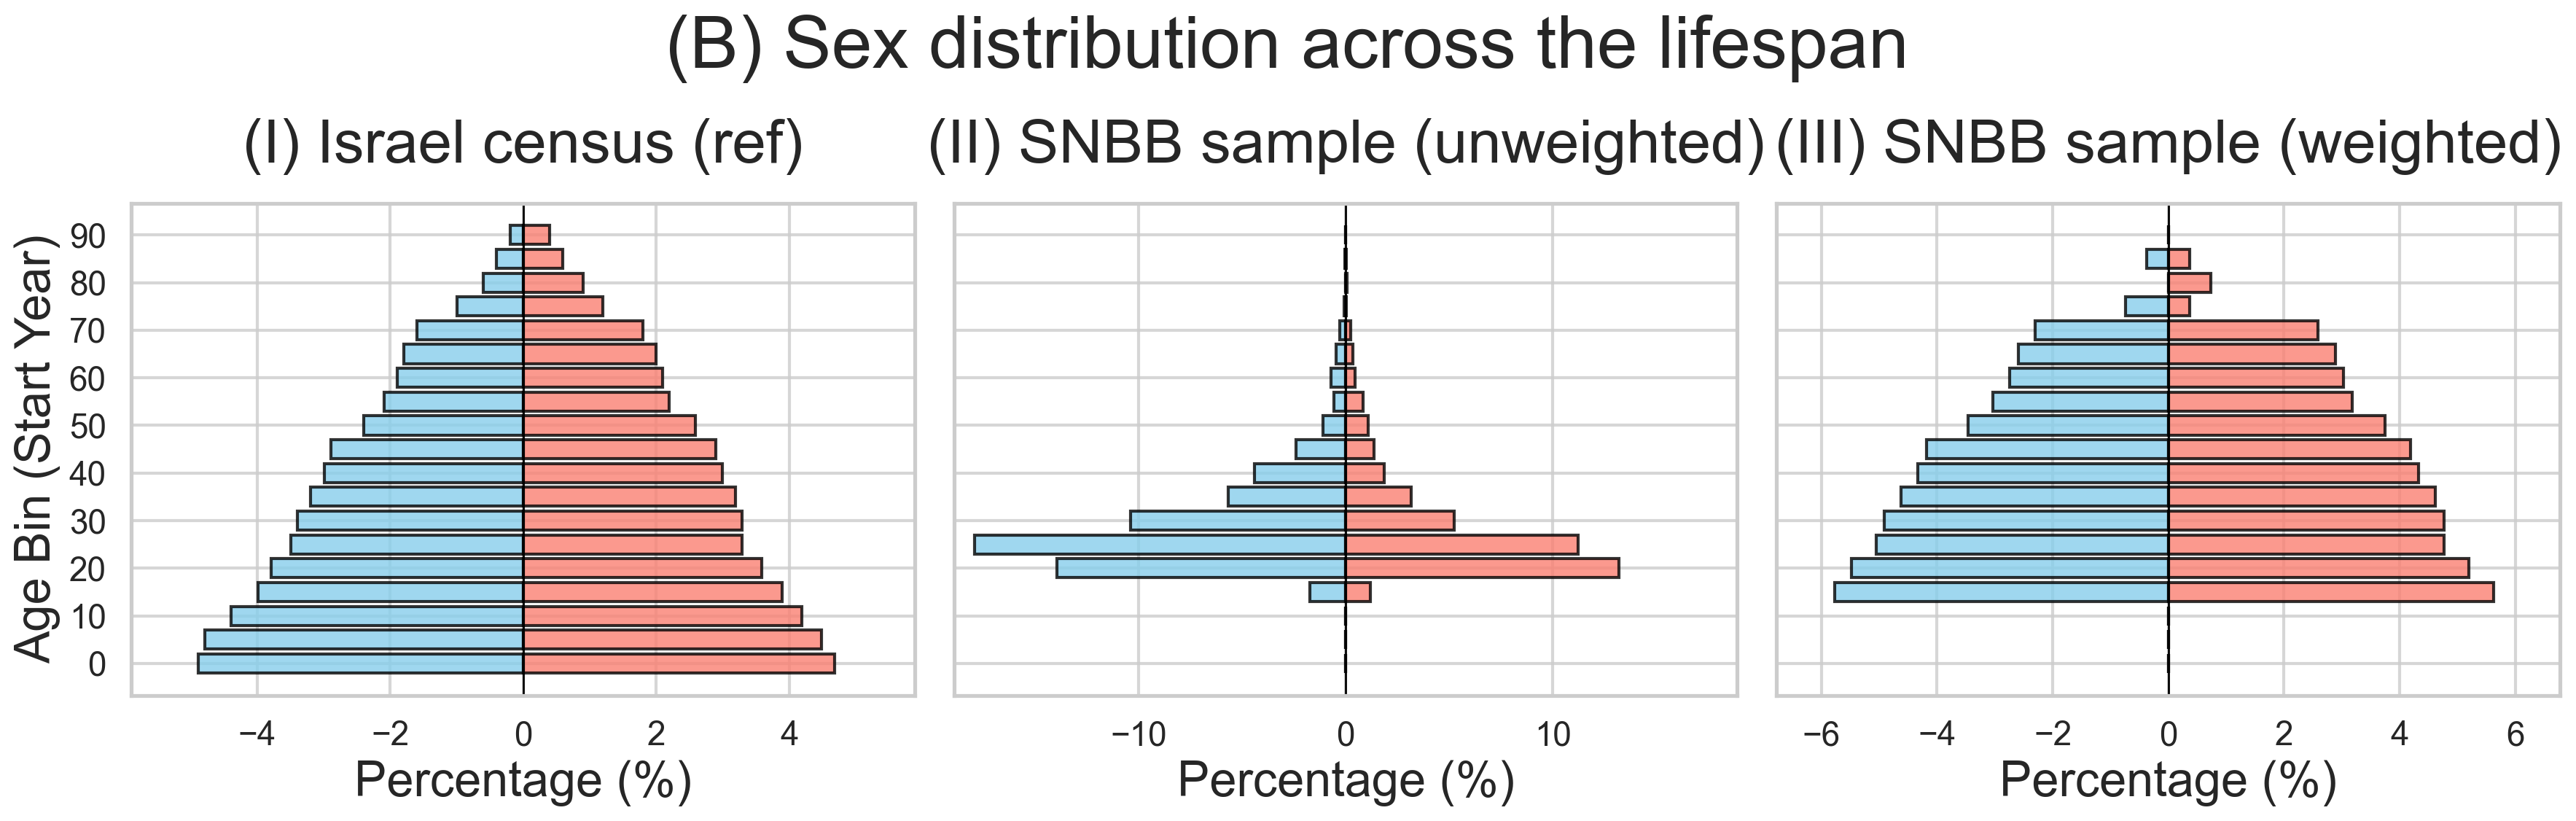

<Figure size 800x400 with 0 Axes>

In [16]:
from neuroaging.visualization import plot_representative_pyramid

fig, fig_legend = plot_representative_pyramid(snbb_age_df, israel_population)
savefig_nice(fig, OUTPUT_DIR.parent / "demographics" / "supp_population_pyramid.png", dpi=400, tight=True)
savefig_nice(fig_legend, OUTPUT_DIR.parent / "demographics" / "supp_population_pyramid_legend.png", dpi=400, tight=True)

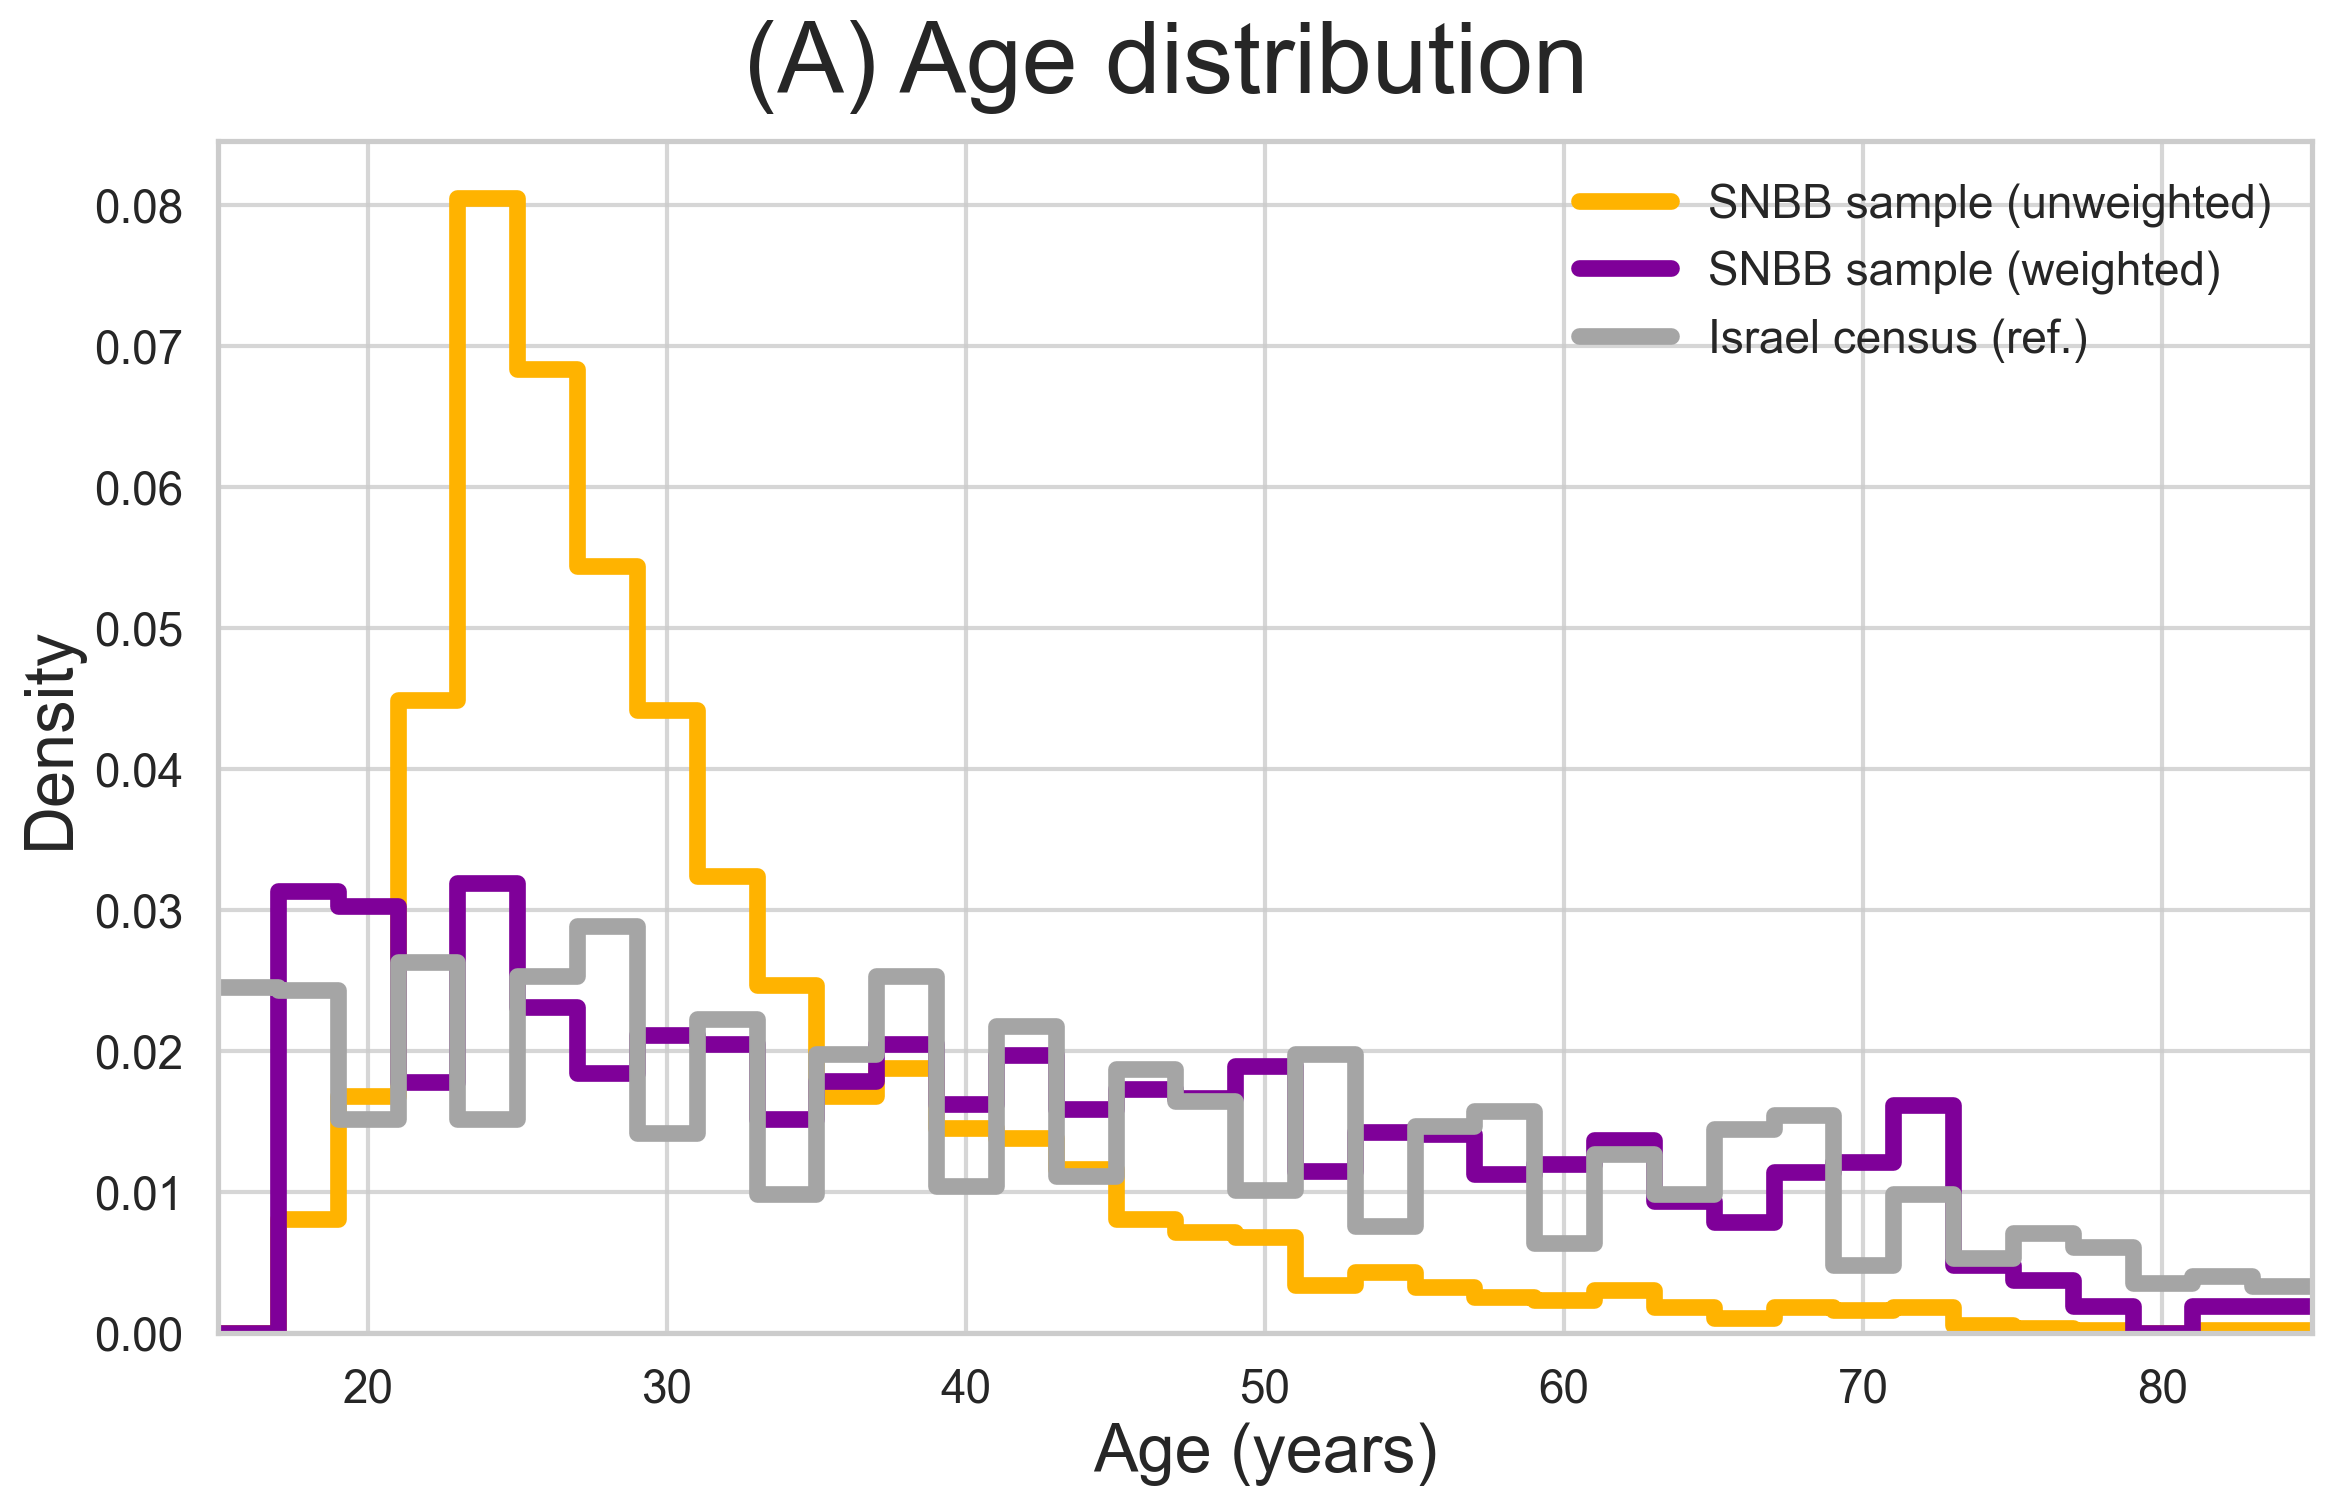

In [17]:
# ── Assumptions ────────────────────────────────────────────────────────────
# • age_df ........ Israeli population           (col: "age_at_scan")
# • snbb_age_df ... Study participants           (cols: "age_at_scan", "weight")
# • The global plotting config cell          has already been run
# • 'metric_col' is *one* brain metric to demo β-shift (e.g., "mean_diffusivity")
from statsmodels.formula.api import ols, wls

# mpl.rcParams.update({"axes.labelsize": 24})
# ── parameters you might tweak ─────────────────────────────────────────────
metric_col = (
    distribution_metric if metric != "gm_vol" else "total_gm_volume"
)  # exemplar column in snbb_age_df
covariates = (
    ["sex"] if metric != "gm_vol" else ["sex", "tiv"]
)  # extra cols in snbb_age_df to control
bin_width = 2  # years
age_min, age_max = 15, 85  # x-axis limits
line_width = 6
# ── figure canvas ─────────────────────────────────────────────────────────-
fig, ax = plt.subplots(figsize=(12, 8))

# ─────────────────────── Panel A: Age distribution ────────────────────────
bins = list(np.arange(age_min, age_max + bin_width, bin_width))  # ←  LIST


# Raw sample
sns.histplot(
    snbb_age_df,
    x="age_at_scan",
    bins=bins,
    stat="density",
    element="step",
    fill=False,
    label="SNBB sample (unweighted)",
    linewidth=line_width,
    color=COL_RAW,
    ax=ax,
)
# Weighted sample
sns.histplot(
    snbb_age_df,
    x="age_at_scan",
    bins=bins,
    weights="weight",
    stat="density",
    element="step",
    fill=False,
    label="SNBB sample (weighted)",
    linewidth=line_width,
    color=COL_WEIGHTED,
    ax=ax,
)
# Population
sns.histplot(
    age_df,
    x="age_at_scan",
    bins=bins,
    stat="density",
    element="step",
    fill=False,
    color=COL_CENSUS,
    label="Israel census (ref.)",
    linewidth=line_width,
    ax=ax,
)


ax.set(xlabel="Age (years)", ylabel="Density", xlim=(age_min, age_max))
# ax.set_title("(A) Age distribution", fontsize=36, pad=20)
plt.suptitle("(A) Age distribution", fontsize=36, y=0.95)
ax.set_ylabel("Density", fontsize=24)
ax.set_xlabel("Age (years)", fontsize=24)
ax.legend(frameon=False)

savefig_nice(
    fig,
    OUTPUT_DIR.parent / "demographics" / "fig1a_age_distribution.png",
    tight=True,
    dpi=400,
)

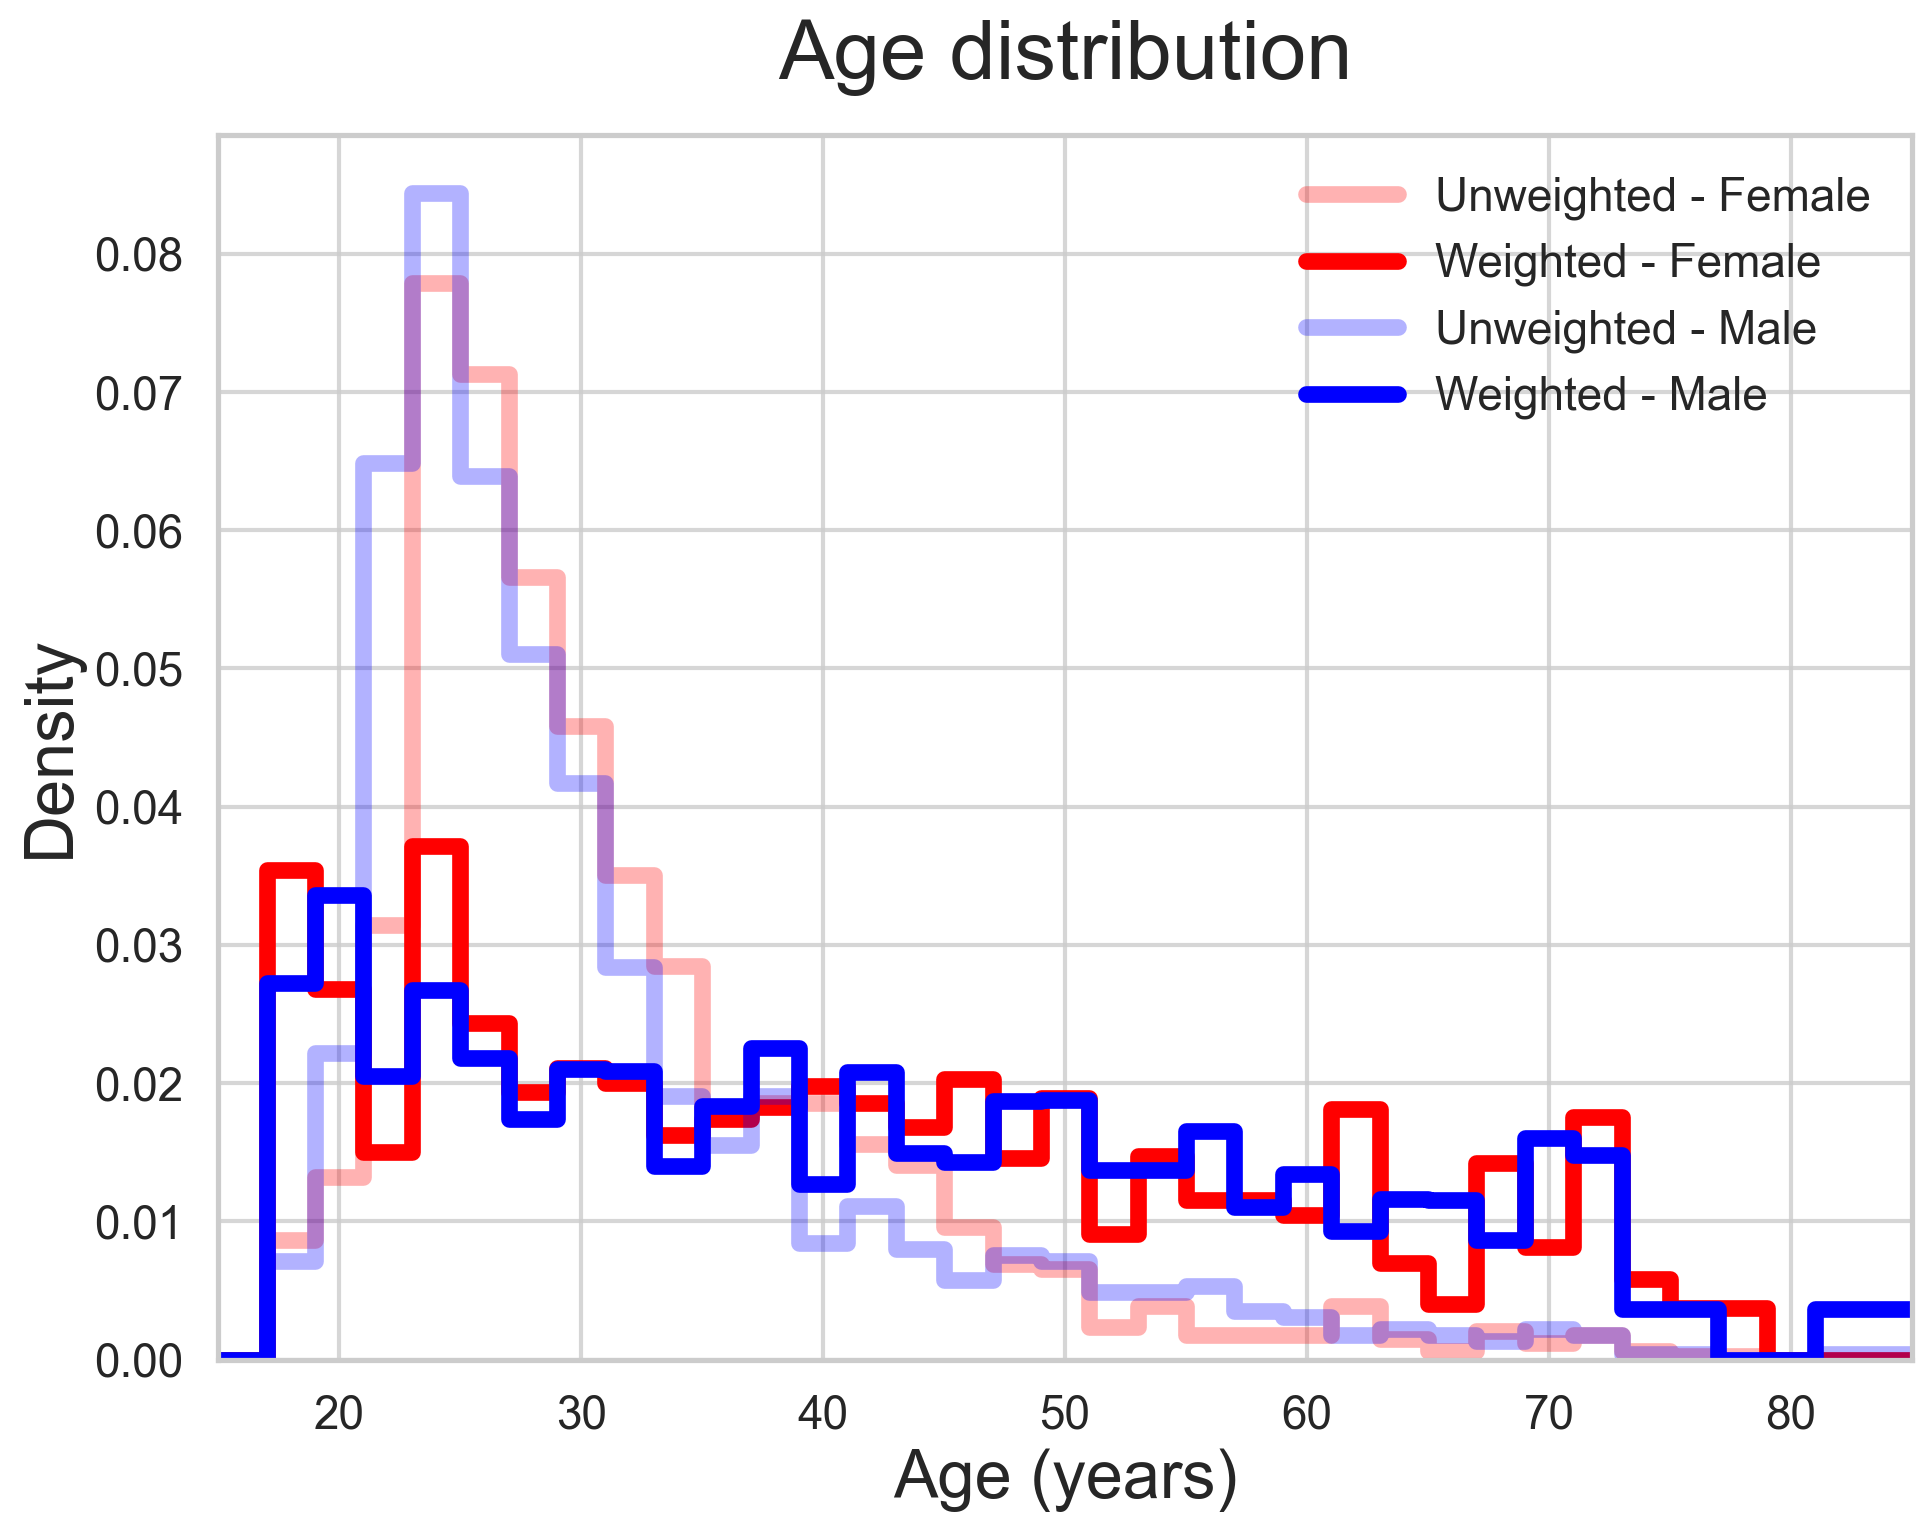

In [18]:
# ── Assumptions ────────────────────────────────────────────────────────────
# • age_df ........ Israeli population           (col: "age_at_scan")
# • snbb_age_df ... Study participants           (cols: "age_at_scan", "weight")
# • The global plotting config cell          has already been run
# • 'metric_col' is *one* brain metric to demo β-shift (e.g., "mean_diffusivity")
from statsmodels.formula.api import ols, wls

# mpl.rcParams.update({"axes.labelsize": 24})
bin_width = 2  # years
age_min, age_max = 15, 85  # x-axis limits
line_width = 6
# ── figure canvas ─────────────────────────────────────────────────────────-
fig, ax = plt.subplots(figsize=(10, 8))

# ─────────────────────── Panel A: Age distribution ────────────────────────
bins = list(np.arange(age_min, age_max + bin_width, bin_width))  # ←  LIST

for s_number, s_title, c in zip([0,1], ["Female","Male"], ["red", "blue"]):
    s_df = snbb_age_df[snbb_age_df["sex"] == s_number]
    sns.histplot(
        s_df,
        x="age_at_scan",
        bins=bins,
        stat="density",
        element="step",
        fill=False,
        linewidth=line_width,
        color=c,
        label=f"Unweighted - {s_title}",
        ax=ax,
        alpha=0.3,
    )
    # Weighted sample
    sns.histplot(
        s_df,
        x="age_at_scan",
        bins=bins,
        weights="weight",
        stat="density",
        element="step",
        fill=False,
        label=f"Weighted - {s_title}",
        linewidth=line_width,
        color=c,
        ax=ax,
    )


ax.set(xlabel="Age (years)", ylabel="Density", xlim=(age_min, age_max))
ax.set_title("Age distribution", fontsize=30, pad=20)
ax.set_ylabel("Density", fontsize=24)
ax.set_xlabel("Age (years)", fontsize=24)
ax.legend(frameon=False)

savefig_nice(
    fig,
    OUTPUT_DIR / "fig1b_age_distribution.png",
    tight=True,
    dpi=300,
)

In [19]:
from neuroaging.modeling import vertex_age, stabilization_age, ORIENTATION

# Use ORIENTATION from module instead of defining here


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

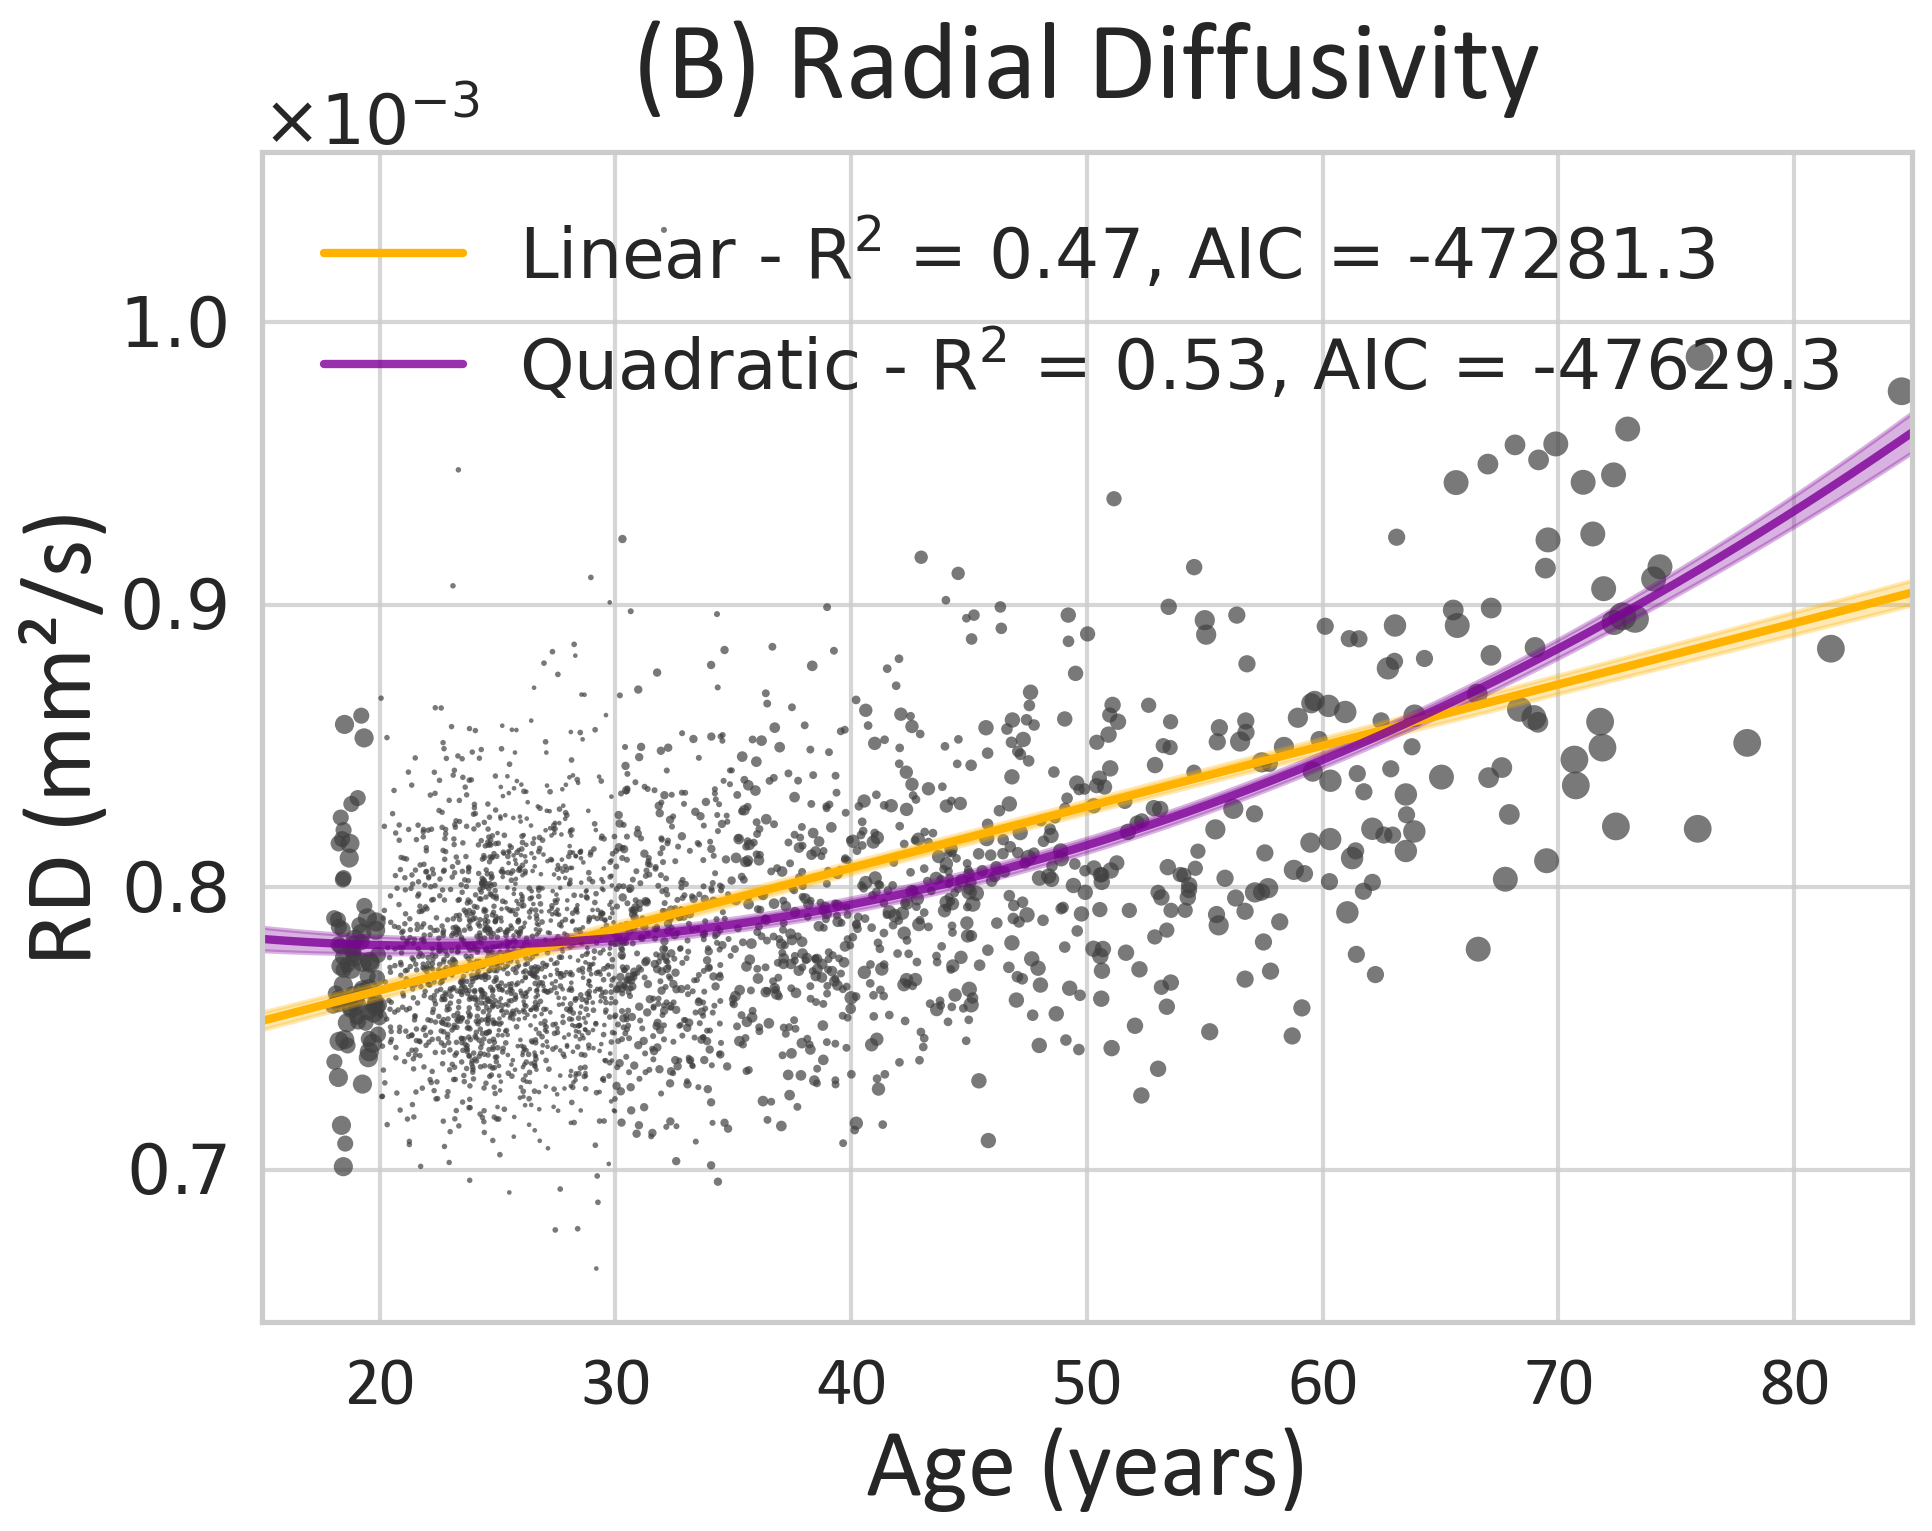

In [20]:
# Toggle centering of age predictor
DRAW_APSI = False
CENTER_VARIABLES = True
USE_WEIGHTS = True
age_min, age_max = 15, 85  # x-axis limits
# 4.  Colour constants for this project (optional convenience)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want
# ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

fig, ax = plt.subplots(figsize=(10, 8))

# set plotting parameters - tick label size, label size, legend font size
mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

for m in [metric] if isinstance(metric, str) else metric:
    if m == "gm_vol":
        snbb_age_df = data_global_dict[m][
            [
                "age_at_scan",
                "sex",
                "tiv",
                distribution_metric,
                "strip_score",
                "subject_code",
                "session_id",
            ]
        ].rename(columns={distribution_metric: "total_gm_volume"}).copy()
    else:
        snbb_age_df = data_global_dict[m][["age_at_scan", "sex", "subject_code", distribution_metric]].copy()
    # snbb_age_df["weight"] = assign_weights_by_population(data=snbb_age_df, population_df=israel_population, age_col="age_at_scan")
    # snbb_age_df["weight"], bin_tbl = compute_poststrat_weights(
    #     snbb_age_df,
    #     israel_population,
    #     age_col="age_at_scan",
    #     cap=None,  # try None first; if still spiky, use 4 or 5
    #     return_bin_table=True,
    # )
    snbb_age_df["sex"] = snbb_age_df["sex"].map({"M": 0, "F": 1})
    snbb_age_df["weight"], bin_tbl = compute_joint_poststrat_weights(
        snbb_age_df,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )
    
    # ── parameters you might tweak ─────────────────────────────────────────────
    metric_col = (
        distribution_metric if m != "gm_vol" else "total_gm_volume"
    )  # exemplar column in snbb_age_df
    # 1. Choose model form
    age_mean = snbb_age_df["age_at_scan"].mean()
    if CENTER_VARIABLES:
        covariates = (
            ["sex"] if m != "gm_vol" else ["sex", "tiv_c"]
        )  # extra cols in snbb_age_df to control
        age_col = "age_c"
        if "vol" in m:
            snbb_age_df["tiv_c"] = snbb_age_df["tiv"] - snbb_age_df["tiv"].mean()
        snbb_age_df["age_c"] = snbb_age_df["age_at_scan"] - age_mean
        lin_terms = ["age_c"] + covariates
        quad_terms = ["age_c", "I(age_c**2)"] + covariates
        lin_formula = f"{metric_col} ~ " + " + ".join(lin_terms)
        quad_formula = f"{metric_col} ~ " + " + ".join(quad_terms)
        age_min_grid = age_min - age_mean
        age_max_grid = age_max - age_mean
    else:
        covariates = (
            ["sex"] if m != "gm_vol" else ["sex", "tiv"]
        )  # extra cols in snbb_age_df to control
        age_col = "age_at_scan"
        lin_terms = ["age_at_scan"] + covariates
        quad_terms = ["age_at_scan", "I(age_at_scan**2)"] + covariates
        lin_formula = f"{metric_col} ~ " + " + ".join(lin_terms)
        quad_formula = f"{metric_col} ~ " + " + ".join(quad_terms)

    # 2. Fit models
    # mod_unw = ols(formula, data=snbb_age_df).fit()
    if USE_WEIGHTS:
        mod_lin = wls(lin_formula, data=snbb_age_df, weights=snbb_age_df["weight"]).fit()
        mod_quad = wls(quad_formula, data=snbb_age_df, weights=snbb_age_df["weight"]).fit()
    else:
        mod_lin = ols(lin_formula, data=snbb_age_df).fit()
        mod_quad = ols(quad_formula, data=snbb_age_df).fit()

    # 3. Prediction frame
    age_grid = np.linspace(age_min_grid, age_max_grid, 300)
    visual_age_grid = age_grid + (age_mean if CENTER_VARIABLES else 0)
    pred_df = pd.DataFrame({age_col: age_grid})
    # fill static covariates with their median / mode
    for cov in covariates:
        if snbb_age_df[cov].dtype.kind in "bifc":  # numeric
            pred_df[cov] = snbb_age_df[cov].median()
        else:  # categorical
            pred_df[cov] = snbb_age_df[cov].mode()[0]

    # 4. Get predictions & CI
    for tag, model in [("Linear", mod_lin), ("Quadratic", mod_quad)]:
        pr = model.get_prediction(pred_df)
        ci = pr.conf_int(alpha=0.05)
        # get predictions in terms of original metric
        pred_df[f"{tag}_fit"] = pr.predicted_mean
        pred_df[f"{tag}_lo"] = ci[:, 0]
        pred_df[f"{tag}_hi"] = ci[:, 1]

    # 5. Plot
    ax.clear()  # reuse the same axes handle

    # Background scatter (down-sample for speed / clarity)
    sizes = np.clip(snbb_age_df["weight"] * 10, 0, 100)
    sns.scatterplot(
        data=snbb_age_df,
        x="age_at_scan",
        y=metric_col,
        alpha=0.7,
        s=sizes,
        edgecolor="none",
        ax=ax,
        legend=False,
        color=COL_REF,
    )

    # # Fit lines & ribbons
    for tag, color, model in zip(
        ["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [mod_lin, mod_quad]
    ):
        label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {model.aic:.1f}"
        ax.plot(visual_age_grid, pred_df[f"{tag}_fit"], label=label, lw=3, color=color)
        ax.fill_between(
            visual_age_grid,
            pred_df[f"{tag}_lo"],
            pred_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

    if m == "gm_vol":
        ylabel = "GM Volume (mm³)"
        title = "(A) GM Volume"
        # set y axis format to cm instead of mm
    elif m == "adc":
        ylabel = "MD (mm²/s)"
        title = "(B) Mean Diffusivity"
    elif m == "ad":
        ylabel = "AD (mm²/s)"
        title = "(A) Axial Diffusivity"
    elif m == "rd":
        ylabel = "RD (mm²/s)"
        title = "(B) Radial Diffusivity"
    elif m == "fa":
        ylabel = "FA"
        title = "(C) Fractional Anisotropy"
        ax.set_ylim(top=snbb_age_df[metric_col].quantile(0.99))
    else:
        raise ValueError(f"Unknown metric: {m}")

    if m != "fa":
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)


    ax.set(
        xlabel="Age (years)",
        ylabel=ylabel,
        xlim=(age_min, age_max)
    )

    # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"

    # ax.set_title("Predicted trajectory (± 95 % CI)")
    ax.set_title(title, fontsize=40, pad=20)

    if DRAW_APSI:
        beta1 = mod_quad.params["age_at_scan"] if not CENTER_VARIABLES else mod_quad.params["age_c"]
        beta2 = mod_quad.params["I(age_at_scan ** 2)"] if not CENTER_VARIABLES else mod_quad.params["I(age_c ** 2)"]
        p1 = mod_quad.pvalues["age_at_scan"] if not CENTER_VARIABLES else mod_quad.pvalues["age_c"]
        p2 = mod_quad.pvalues["I(age_at_scan ** 2)"] if not CENTER_VARIABLES else mod_quad.pvalues["I(age_c ** 2)"]
        age_star, clipped, u = stabilization_age(
                        m,
                        {"age": beta1, "age_sq": beta2},
                        age_mean if CENTER_VARIABLES else 0,
                        # age_min=data["age_at_scan"].min(),
                        # age_max=data["age_at_scan"].max(),
                    )
        if age_star > 18:
            lab = f"Peak Structural Integrity (APSI) = {age_star:.1f} years"
        else:
            lab = f"Peak Structural Integrity (APSI) ≤ {age_star:.1f} years"
        ax.axvline(
            age_star,
            color="green",
            linestyle="--",
            lw=5,
            label=lab,
        )


    ax.legend(frameon=False, fontsize=25, loc="upper left")

    # # set tick label size
    # for tick in ax.get_xticklabels() + ax.get_yticklabels():
    #     tick.set_fontsize(30)

    # # set label size
    # ax.set_xlabel("Age (years)", fontsize=30)
    # ax.set_ylabel(ylabel, fontsize=30)


    # model_type = "quad" if use_quadratic else "linear"
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig1_{m}.png" if USE_WEIGHTS else OUTPUT_DIR / f"fig1_{m}_unweighted.png",
        tight=True,
        dpi=300,
    )
    # break

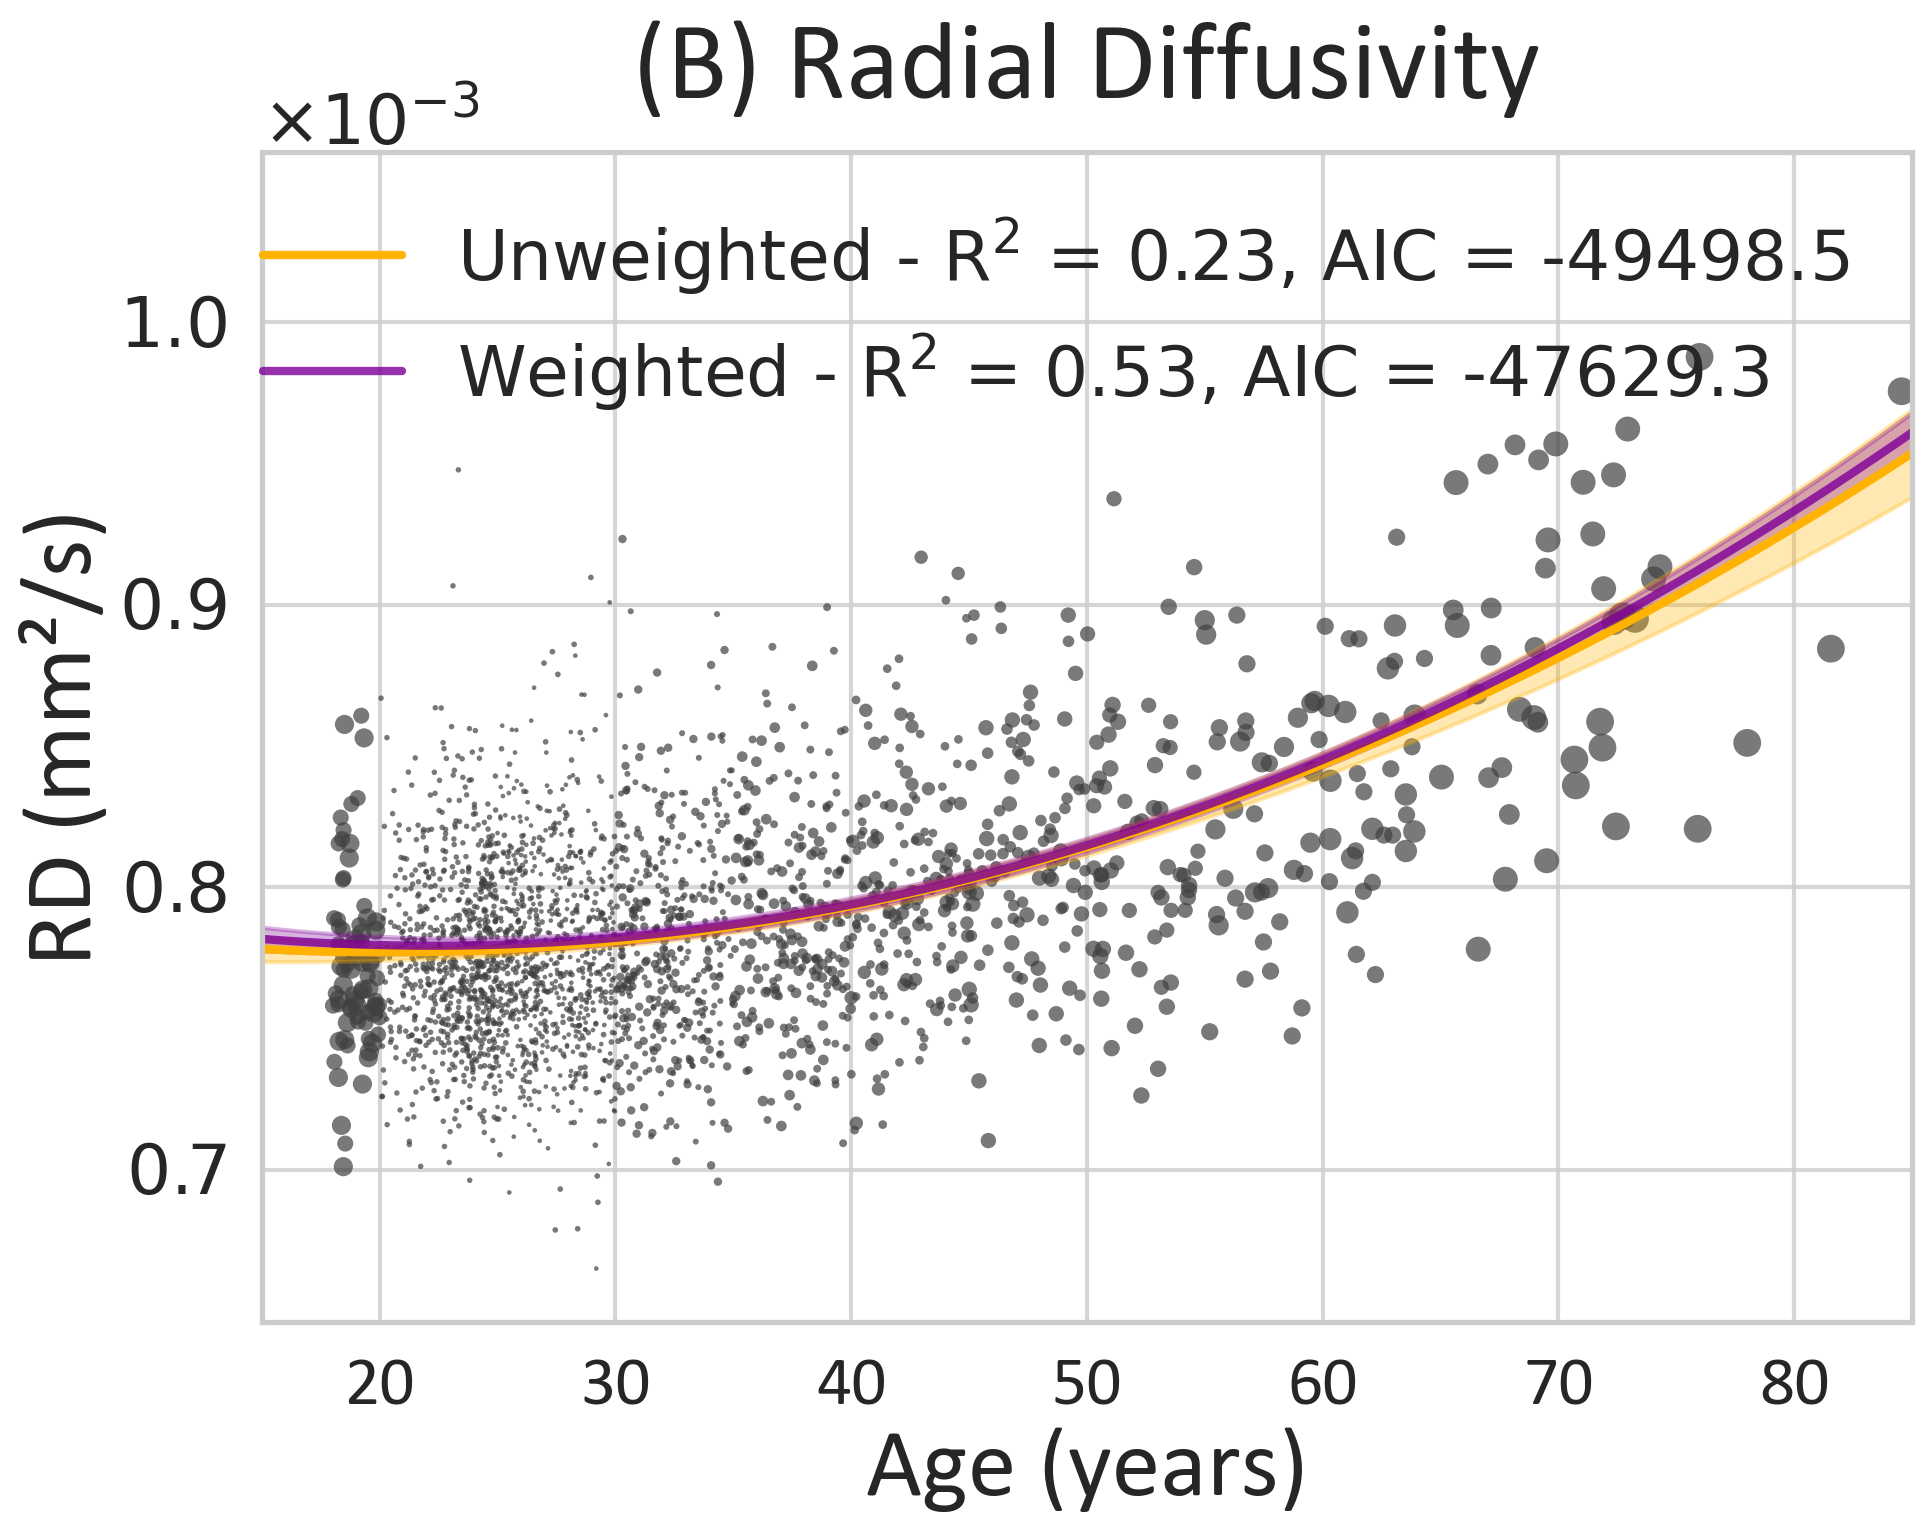

In [21]:
# Toggle centering of age predictor
DRAW_APSI = False
CENTER_VARIABLES = True
USE_WEIGHTS = False
age_min, age_max = 15, 85  # x-axis limits
# 4.  Colour constants for this project (optional convenience)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want
# ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

fig, ax = plt.subplots(figsize=(10, 8))

# set plotting parameters - tick label size, label size, legend font size
mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

for m in [metric] if isinstance(metric, str) else metric:
    if m == "gm_vol":
        snbb_age_df = data_global_dict[m][
            [
                "age_at_scan",
                "sex",
                "tiv",
                distribution_metric,
                "strip_score",
                "subject_code",
                "session_id",
            ]
        ].rename(columns={distribution_metric: "total_gm_volume"}).copy()
    else:
        snbb_age_df = data_global_dict[m][["age_at_scan", "sex", "subject_code", distribution_metric]].copy()
    # snbb_age_df["weight"] = assign_weights_by_population(data=snbb_age_df, population_df=israel_population, age_col="age_at_scan")
    # snbb_age_df["weight"], bin_tbl = compute_poststrat_weights(
    #     snbb_age_df,
    #     israel_population,
    #     age_col="age_at_scan",
    #     cap=None,  # try None first; if still spiky, use 4 or 5
    #     return_bin_table=True,
    # )
    snbb_age_df["sex"] = snbb_age_df["sex"].map({"M": 0, "F": 1})
    snbb_age_df["weight"], bin_tbl = compute_joint_poststrat_weights(
        snbb_age_df,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )
    
    # ── parameters you might tweak ─────────────────────────────────────────────
    metric_col = (
        distribution_metric if m != "gm_vol" else "total_gm_volume"
    )  # exemplar column in snbb_age_df
    # 1. Choose model form
    age_mean = snbb_age_df["age_at_scan"].mean()
    if CENTER_VARIABLES:
        covariates = (
            ["sex"] if m != "gm_vol" else ["sex", "tiv_c"]
        )  # extra cols in snbb_age_df to control
        age_col = "age_c"
        if "vol" in m:
            snbb_age_df["tiv_c"] = snbb_age_df["tiv"] - snbb_age_df["tiv"].mean()
        snbb_age_df["age_c"] = snbb_age_df["age_at_scan"] - age_mean
        lin_terms = ["age_c"] + covariates
        quad_terms = ["age_c", "I(age_c**2)"] + covariates
        lin_formula = f"{metric_col} ~ " + " + ".join(lin_terms)
        quad_formula = f"{metric_col} ~ " + " + ".join(quad_terms)
        age_min_grid = age_min - age_mean
        age_max_grid = age_max - age_mean
    else:
        covariates = (
            ["sex"] if m != "gm_vol" else ["sex", "tiv"]
        )  # extra cols in snbb_age_df to control
        age_col = "age_at_scan"
        lin_terms = ["age_at_scan"] + covariates
        quad_terms = ["age_at_scan", "I(age_at_scan**2)"] + covariates
        lin_formula = f"{metric_col} ~ " + " + ".join(lin_terms)
        quad_formula = f"{metric_col} ~ " + " + ".join(quad_terms)

    # 2. Fit models
    # mod_unw = ols(formula, data=snbb_age_df).fit()
    mod_unw = ols(quad_formula, data=snbb_age_df).fit()
    mod_wtd = wls(quad_formula, data=snbb_age_df, weights=snbb_age_df["weight"]).fit()

    # 3. Prediction frame
    age_grid = np.linspace(age_min_grid, age_max_grid, 300)
    visual_age_grid = age_grid + (age_mean if CENTER_VARIABLES else 0)
    pred_df = pd.DataFrame({age_col: age_grid})
    # fill static covariates with their median / mode
    for cov in covariates:
        if snbb_age_df[cov].dtype.kind in "bifc":  # numeric
            pred_df[cov] = snbb_age_df[cov].median()
        else:  # categorical
            pred_df[cov] = snbb_age_df[cov].mode()[0]

    # 4. Get predictions & CI
    for tag, model in [("Unweighted", mod_unw), ("Weighted", mod_wtd)]:
        pr = model.get_prediction(pred_df)
        ci = pr.conf_int(alpha=0.05)
        # get predictions in terms of original metric
        pred_df[f"{tag}_fit"] = pr.predicted_mean
        pred_df[f"{tag}_lo"] = ci[:, 0]
        pred_df[f"{tag}_hi"] = ci[:, 1]

    # 5. Plot
    ax.clear()  # reuse the same axes handle

    # Background scatter (down-sample for speed / clarity)
    sizes = np.clip(snbb_age_df["weight"] * 10, 0, 100)
    sns.scatterplot(
        data=snbb_age_df,
        x="age_at_scan",
        y=metric_col,
        alpha=0.7,
        s=sizes,
        edgecolor="none",
        ax=ax,
        legend=False,
        color=COL_REF,
    )

    # # Fit lines & ribbons
    for tag, color, model in zip(
        ["Unweighted", "Weighted"], [COL_RAW, COL_WEIGHTED], [mod_unw, mod_wtd]
    ):
        label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {model.aic:.1f}"
        if DRAW_APSI:
            beta1 = model.params["age_at_scan"] if not CENTER_VARIABLES else model.params["age_c"]
            beta2 = model.params["I(age_at_scan ** 2)"] if not CENTER_VARIABLES else model.params["I(age_c ** 2)"]
            p1 = model.pvalues["age_at_scan"] if not CENTER_VARIABLES else model.pvalues["age_c"]
            p2 = model.pvalues["I(age_at_scan ** 2)"] if not CENTER_VARIABLES else model.pvalues["I(age_c ** 2)"]
            age_star, clipped, u = stabilization_age(
                            m,
                            {"age": beta1, "age_sq": beta2},
                            age_mean if CENTER_VARIABLES else 0,
                            # age_min=data["age_at_scan"].min(),
                            # age_max=data["age_at_scan"].max(),
                        )
            if age_star > 18:
                lab = f"Vertex = {age_star:.1f} years"
            else:
                lab = f"Vertex ≤ {age_star:.1f} years"
            ax.axvline(
                age_star,
                color=color,
                linestyle="--",
                lw=5,
                # label=lab,
            )
            label = label + f"\n{lab}"
        ax.plot(visual_age_grid, pred_df[f"{tag}_fit"], label=label, lw=3, color=color)
        ax.fill_between(
            visual_age_grid,
            pred_df[f"{tag}_lo"],
            pred_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

    if m == "gm_vol":
        ylabel = "GM Volume (mm³)"
        title = "(A) GM Volume"
        # set y axis format to cm instead of mm
    elif m == "adc":
        ylabel = "MD (mm²/s)"
        title = "(B) Mean Diffusivity"
    elif m == "ad":
        ylabel = "AD (mm²/s)"
        title = "(A) Axial Diffusivity"
    elif m == "rd":
        ylabel = "RD (mm²/s)"
        title = "(B) Radial Diffusivity"
    elif m == "fa":
        ylabel = "FA"
        title = "(C) Fractional Anisotropy"
        ax.set_ylim(top=snbb_age_df[metric_col].quantile(0.99))
    else:
        raise ValueError(f"Unknown metric: {m}")

    if m != "fa":
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)


    ax.set(
        xlabel="Age (years)",
        ylabel=ylabel,
        xlim=(age_min, age_max)
    )

    # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"

    # ax.set_title("Predicted trajectory (± 95 % CI)")
    ax.set_title(title, fontsize=40, pad=20)



    ax.legend(frameon=False, fontsize=25, loc="upper right")

    # # set tick label size
    # for tick in ax.get_xticklabels() + ax.get_yticklabels():
    #     tick.set_fontsize(30)

    # # set label size
    # ax.set_xlabel("Age (years)", fontsize=30)
    # ax.set_ylabel(ylabel, fontsize=30)


    # model_type = "quad" if use_quadratic else "linear"
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig1_{m}_comparison.png",
        tight=True,
        dpi=300,
    )
    # break

In [22]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import numpy as np

from neuroaging.modeling import format_value_for_paper, collect_relevant, extract_model_info

extract_model_info(mod_quad, "quadratic", mod_lin)
# extract_model_info(mod_lin, "linear")

{'params': {'Intercept': '0.001'},
 'pvalues': {'Intercept': '0.000'},
 'bse': {'Intercept': '1.13 x 10^-6'},
 'rsquared': '0.528',
 'aic': np.float64(-47629.33571239316),
 'f_stat_q_vs_l': '372.334',
 'p_f_stat_q_vs_l': '5.58 x 10^-78',
 'preferred_model': 'Quadratic'}